### Common plots

In [1]:
lab_names = {
    '50983': 'Sodium',
    '50971': 'Potassium',
    '50902': 'Chloride',
    '50882': 'Bicarbonate',
    '50912': 'Creatinine',
    '51006': 'BUN',
    '50931': 'Glucose',
    '50893': 'Calcium',
    '50868': 'Anion Gap',
    '51222': 'Hemoglobin',
    '51301': 'WBC',
    '51265': 'Platelet Count',
    '51221': 'Hematocrit',
    '51250': 'MCV',
    '51277': 'RDW',
    '50960': 'Magnesium',
    '50970': 'Phosphate',
    '51248': 'MCH',
    '51249': 'MCHC',
    '51279': 'RBC'
}

icd_names = {
    'I10': 'Essential (primary) hypertension',
    'E785': 'Hyperlipidemia, unspecified',
    'K219': 'Gastroesophageal reflux disease without esophagitis',
    'Z87891': 'Personal history of nicotine dependence',
    'I2510': 'Atherosclerotic heart disease of native coronary artery without angina pectoris',
    'N179': 'Acute kidney failure, unspecified',
    'F329': 'Major depressive disorder, single episode, unspecified',
    'I4891': 'Unspecified atrial fibrillation',
    'Z7901': 'Long term (current) use of anticoagulants',
    'F419': 'Anxiety disorder, unspecified',
    'E119': 'Type 2 diabetes mellitus without complications',
    'E039': 'Hypothyroidism, unspecified',
    'Z794': 'Long term (current) use of insulin',
    'D649': 'Anemia, unspecified',
    'N390': 'Urinary tract infection, site not specified'
}

ccsr_names = {
    'FAC021': 'Personal/family history of disease',
    'FAC025': 'Other specified status',
    'END011': 'Fluid and electrolyte disorders',
    'CIR011': 'Coronary atherosclerosis and other heart disease',
    'END010': 'Disorders of lipid metabolism',
    'CIR007': 'Essential hypertension',
    'END003': 'Diabetes mellitus with complication',
    'CIR019': 'Heart failure',
    'DIG004': 'Esophageal disorders',
    'CIR017': 'Cardiac dysrhythmias',
    'CIR008': 'Hypertension with complications and secondary hypertension',
    'BLD003': 'Aplastic anemia',
    'EXT027': 'External cause codes: place of occurrence of the external cause',
    'GEN002': 'Acute and unspecified renal failure',
    'END009': 'Obesity'
}

def map_feature_name(feature_name):
    if feature_name.startswith('lab_') and feature_name.endswith('_daily'):
        code = feature_name.replace('lab_', '').replace('_daily', '')
        if code in lab_names:
            return f"{lab_names[code]} ({code})"
    elif feature_name.startswith('icd_'):
        code = feature_name.replace('icd_', '')
        if code in icd_names:
            return f"{icd_names[code]} ({code})"
    elif feature_name.startswith('ccsr_'):
        code = feature_name.replace('ccsr_', '')
        if code in ccsr_names:
            return f"{ccsr_names[code]} ({code})"
    return feature_name

In [2]:
import pandas as pd
import joblib
import shap

delta_summary = pd.read_csv('delta_summary.csv')
analyzed_features = set(delta_summary['feature'].tolist())

print(f"Analyzed features: {len(analyzed_features)}")

explanation = joblib.load('shap_explanation.pkl')
indices = []
for i, name in enumerate(explanation.feature_names):
    if name in analyzed_features:
        indices.append(i)

print(f"Matching features in explanation: {len(indices)}")

/Users/arinapetuhova/.pyenv/versions/3.13.7/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Analyzed features: 60
Matching features in explanation: 60


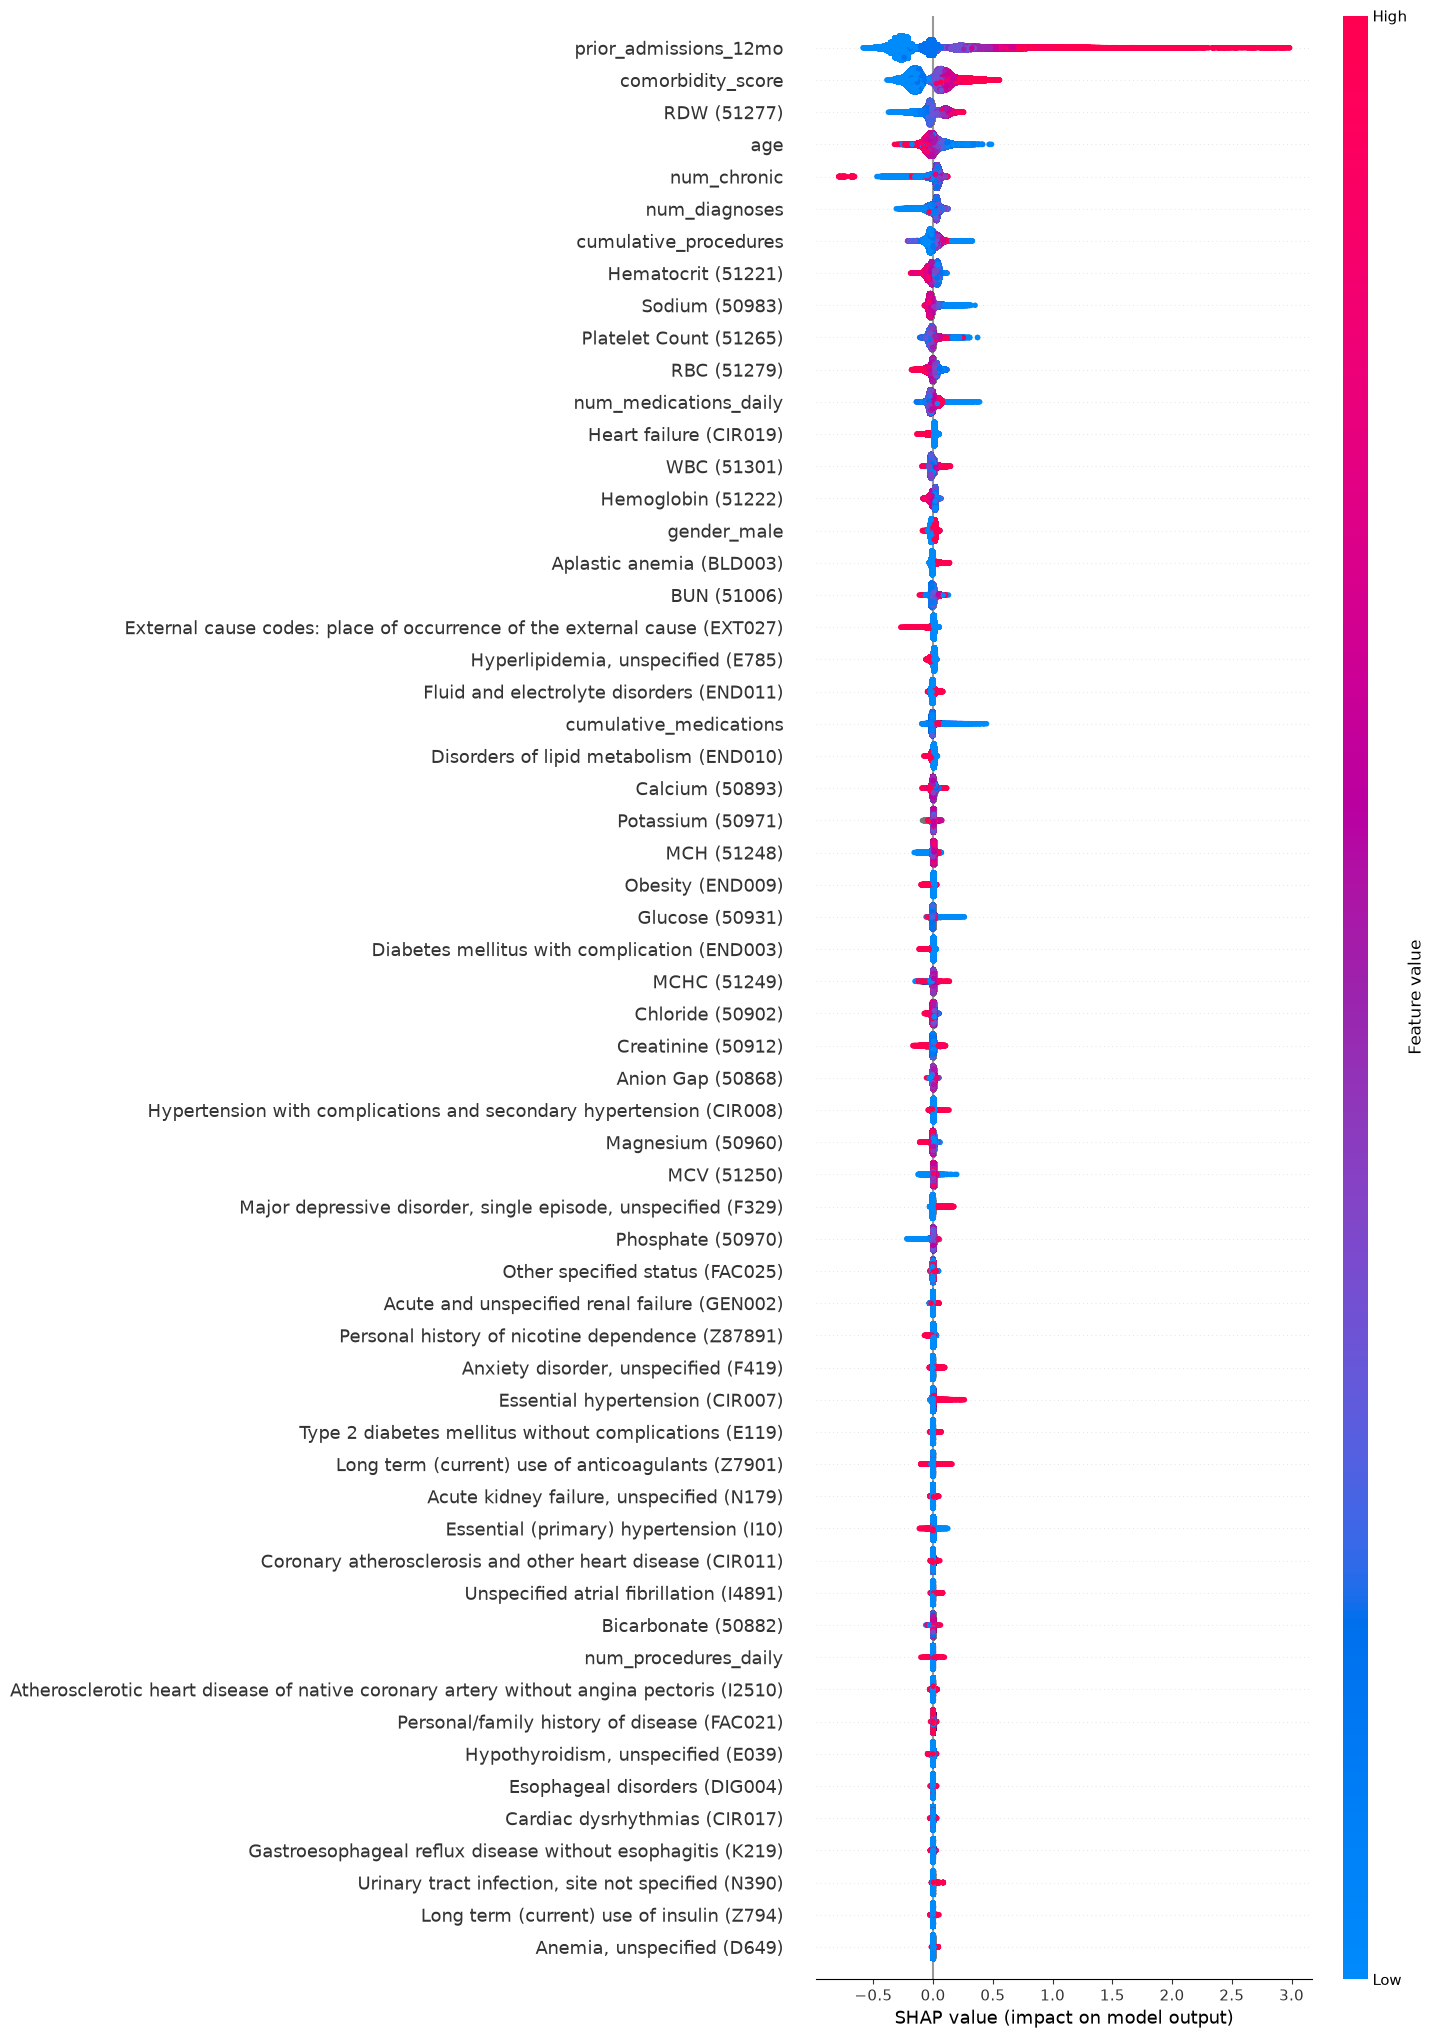

In [3]:
import matplotlib.pyplot as plt
import shap

explanation_filtered = shap.Explanation(
    values=explanation.values[:, indices],
    base_values=explanation.base_values,
    data=explanation.data[:, indices],
    feature_names=[map_feature_name(explanation.feature_names[i]) for i in indices]
)

plt.figure(figsize=(14, 12))
shap.plots.beeswarm(explanation_filtered, max_display=60)
plt.show()

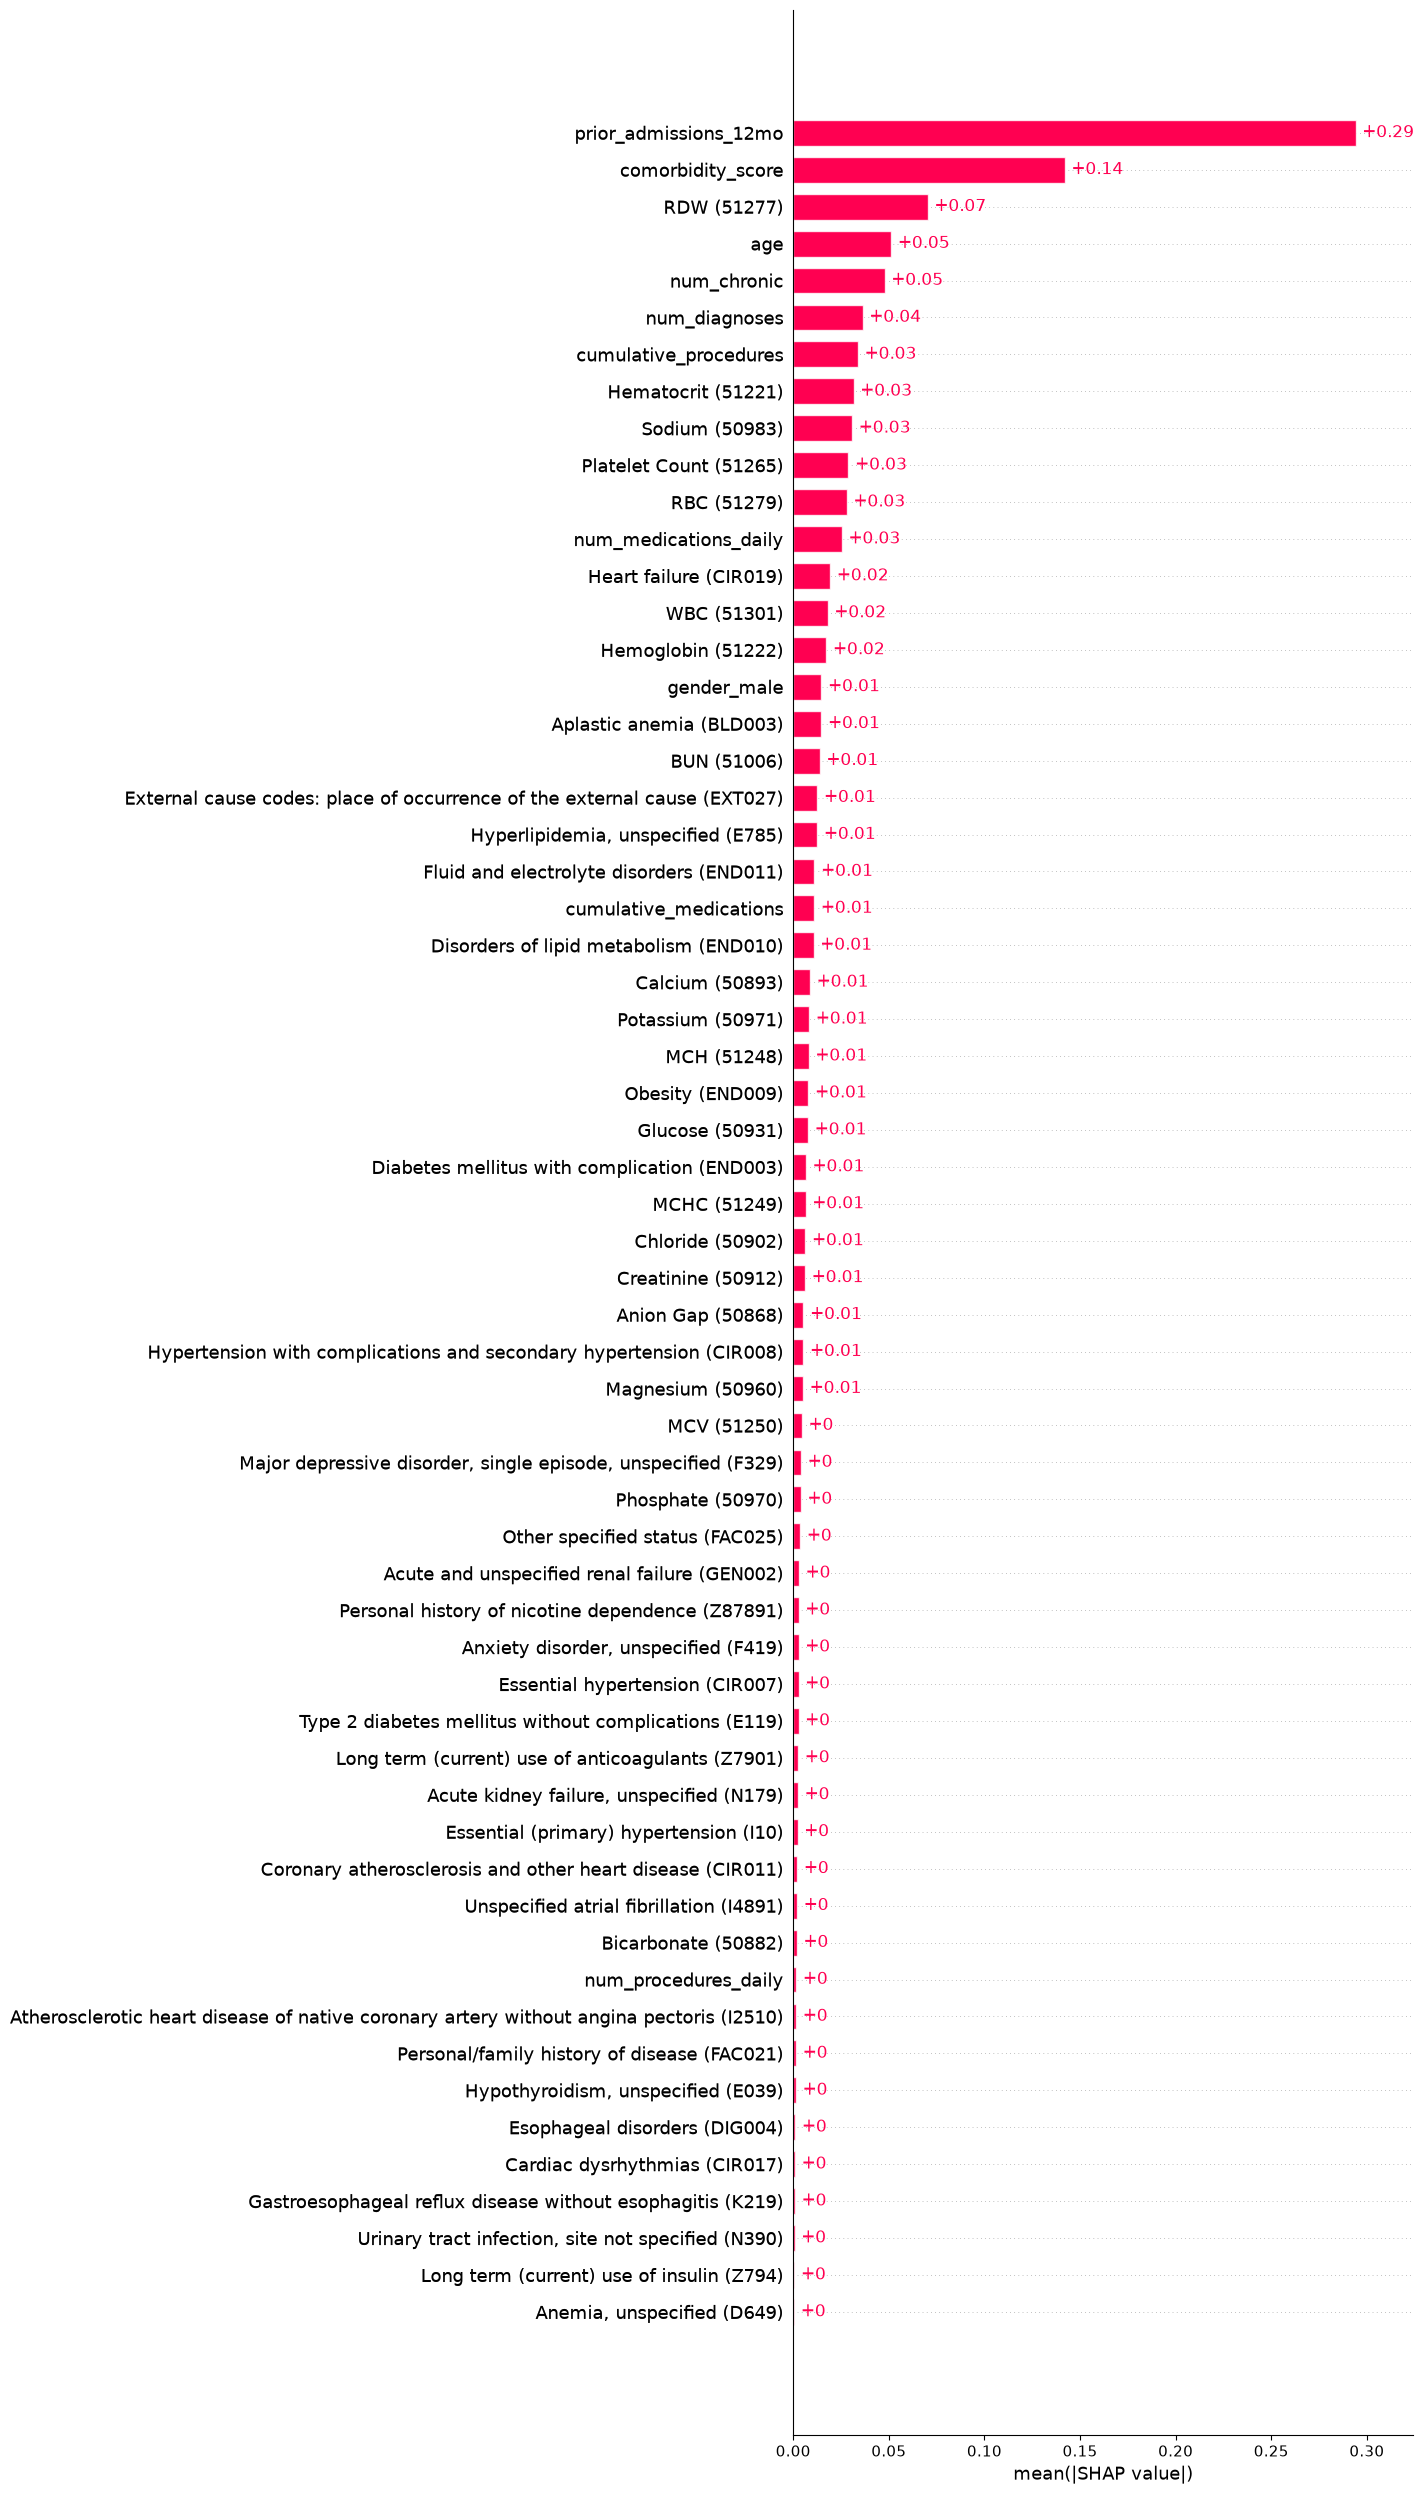

In [4]:
shap.plots.bar(explanation_filtered, max_display=160)

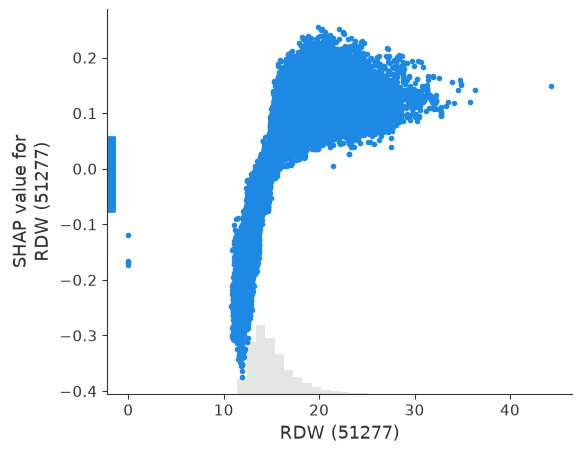

In [5]:
shap.plots.scatter(explanation_filtered[:,"RDW (51277)"])

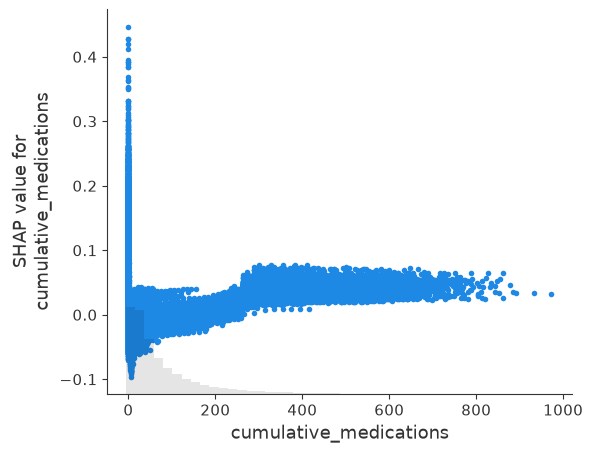

In [6]:
shap.plots.scatter(explanation_filtered[:,"cumulative_medications"])

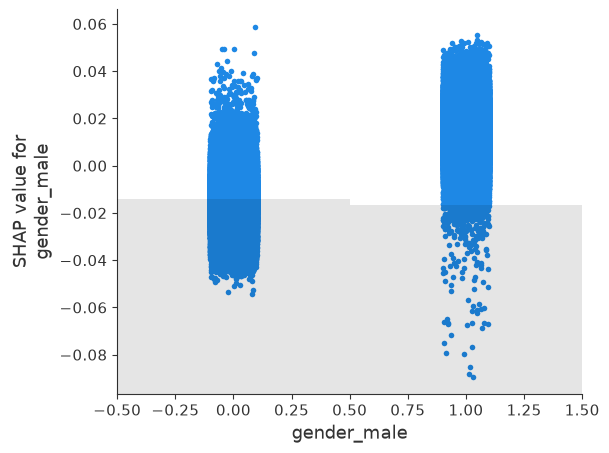

In [7]:
shap.plots.scatter(explanation_filtered[:,"gender_male"])

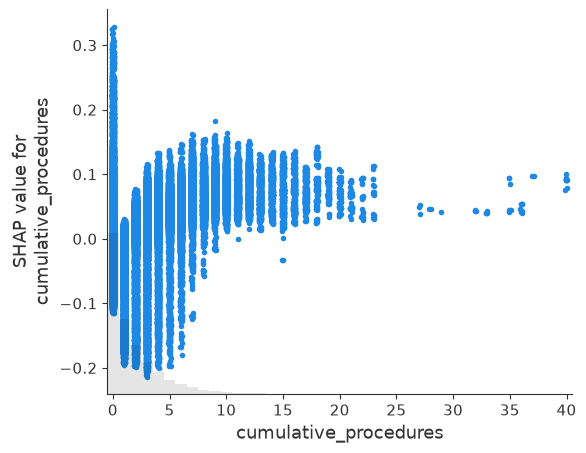

In [8]:
shap.plots.scatter(explanation_filtered[:,"cumulative_procedures"])

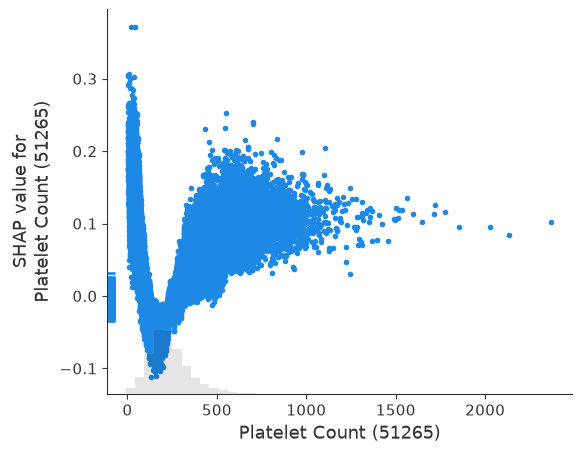

In [9]:
shap.plots.scatter(explanation_filtered[:,"Platelet Count (51265)"])

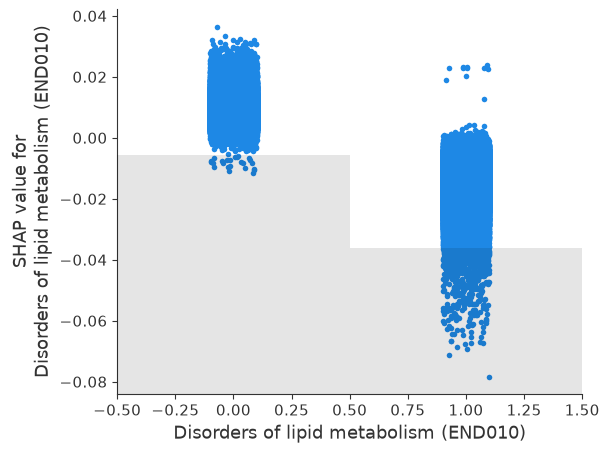

In [10]:
shap.plots.scatter(explanation_filtered[:,"Disorders of lipid metabolism (END010)"])

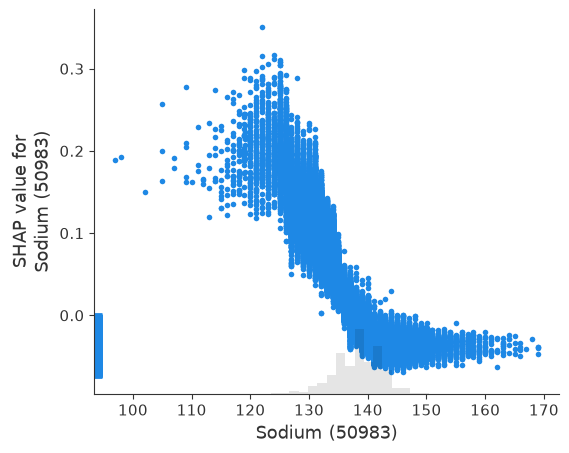

In [11]:
shap.plots.scatter(explanation_filtered[:,"Sodium (50983)"])

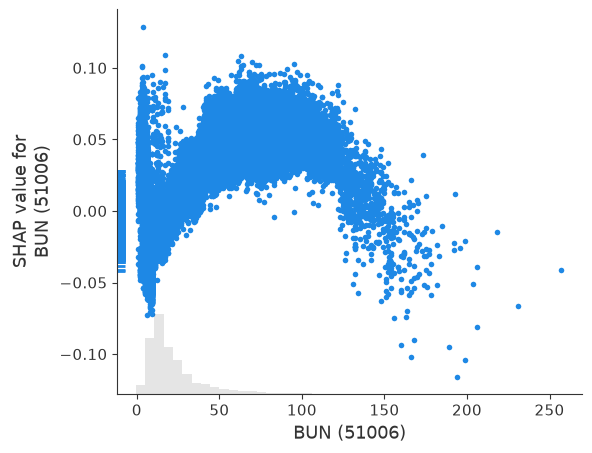

In [12]:
shap.plots.scatter(explanation_filtered[:,"BUN (51006)"])

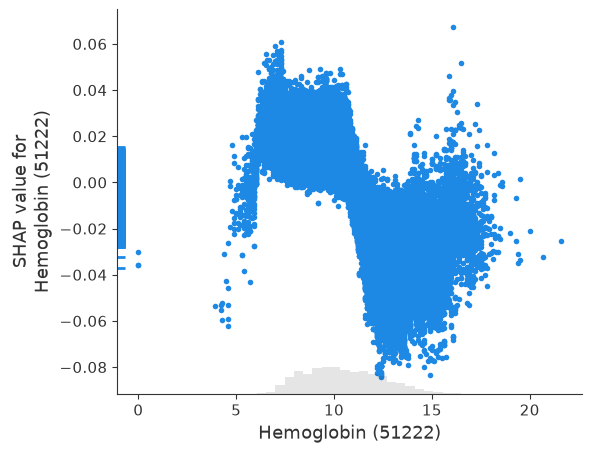

In [13]:
shap.plots.scatter(explanation_filtered[:,"Hemoglobin (51222)"])

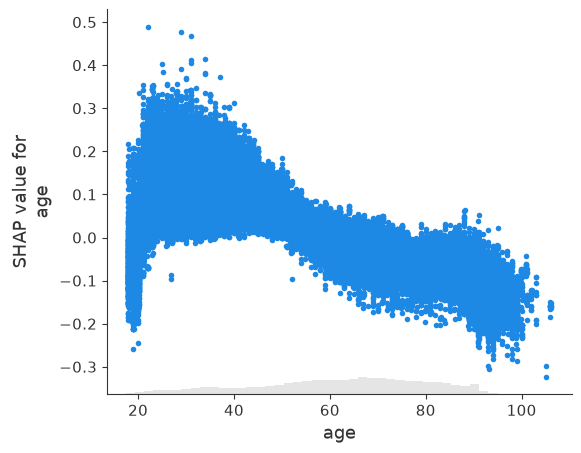

In [14]:
shap.plots.scatter(explanation_filtered[:,"age"])

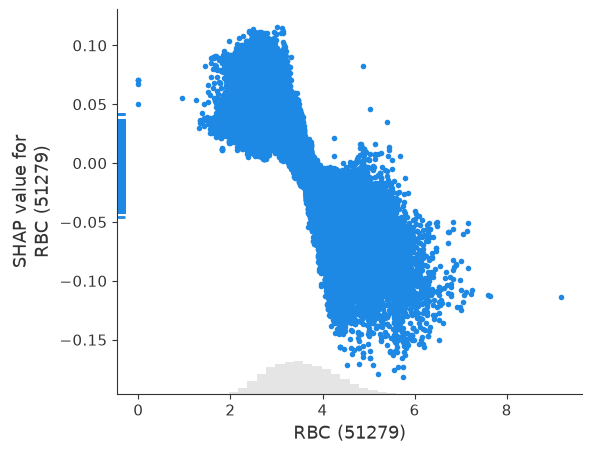

In [15]:
shap.plots.scatter(explanation_filtered[:,"RBC (51279)"])

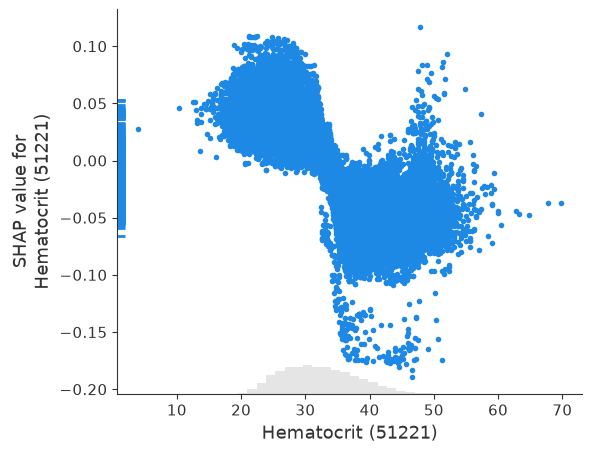

In [16]:
shap.plots.scatter(explanation_filtered[:,"Hematocrit (51221)"])